In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_excel('data_cleaning/data/spread_sheet_for_DIB.xlsx', header=[0,1])
df.rename(columns=str.strip, inplace=True)
df

Unnamed: 0_level_0 SOCIO- DEMOGRAPHIC                                      \
     NO OF RESPONDENTS                SEX AGE RELIGION MARITAL STATUS YES JOB   
0                    1                  2   1        1              2       0   
1                    2                  1   2        1              1       1   
2                    3                  1   3        1              1       1   
3                    4                  2   1        1              1       1   
4                    5                  1   4        1              1       1   
..                 ...                ...  ..      ...            ...     ...   
491                492                  2   1        1              2       0   
492                493                  1   3        2              1       1   
493                494                  2   1        1              2       0   
494                495                  1   2        2              1       2   
495                496                  1   4        1              1       1   

                                                      ... WORK LIFE BALANCE  \
    YES NATURE ETHINITY NATURE OF FAMILY EDUCTAIONAL  ...              WLB4   
0            0        2                2           3  ...                 3   
1            2        1                1           3  ...                 4   
2            1        1                1           4  ...                 5   
3            2        1                1           5  ...                 2   
4            3        2                1           4  ...                 5   
..         ...      ...              ...         ...  ...               ...   
491          0        1                1           3  ...                 3   
492          2        2                1           3  ...                 4   
493          0        1                2           3  ...                 4   
494          0        1                2           3  ...                 4   
495          2        2                2           3  ...                 3   

                                                      
    WLB5 WLB6 WLB7 WLB8 WLB9 WLB10 WLB11 WLB12 WLB13  
0      4    4    4    2    4     3     3     3     1  
1      2    3    2    2    4     2     4     4     2  
2      4    3    2    5    2     3     5     4     3  
3      4    4    3    2    3     3     2     2     2  
4      4    4    2    3    4     2     4     5     2  
..   ...  ...  ...  ...  ...   ...   ...   ...   ...  
491    2    2    3    1    3     2     1     1     3  
492    4    3    2    3    5     3     4     3     5  
493    4    4    3    4    3     2     5     5     2  
494    3    4    3    4    3     3     3     4     2  
495    4    4    2    3    3     1     4     5     3  

[496 rows x 116 columns]

In [2]:
df.drop(columns=['SOCIO- DEMOGRAPHIC', 'EMPLOYMENT STATUS'], axis=1, level=0, inplace=True)
df

Unnamed: 0_level_0 SELF MANAGEMENT                                  ...  \
     NO OF RESPONDENTS             SM1 SM2 SM3 SM4 SM5 SM6 SM7 SM8 SM9  ...   
0                    1               2   2   1   1   1   3   5   4   4  ...   
1                    2               2   2   3   1   3   1   1   2   3  ...   
2                    3               4   4   2   3   2   2   2   5   2  ...   
3                    4               3   2   1   3   4   1   1   1   1  ...   
4                    5               3   2   2   1   5   2   1   1   1  ...   
..                 ...             ...  ..  ..  ..  ..  ..  ..  ..  ..  ...   
491                492               2   2   2   2   3   4   1   2   2  ...   
492                493               4   5   2   5   4   4   2   3   4  ...   
493                494               5   4   2   2   1   1   1   5   2  ...   
494                495               3   3   2   3   2   4   2   4   4  ...   
495                496               3   3   3   2   1   1   3   2   2  ...   

    WORK LIFE BALANCE                                                   
                 WLB4 WLB5 WLB6 WLB7 WLB8 WLB9 WLB10 WLB11 WLB12 WLB13  
0                   3    4    4    4    2    4     3     3     3     1  
1                   4    2    3    2    2    4     2     4     4     2  
2                   5    4    3    2    5    2     3     5     4     3  
3                   2    4    4    3    2    3     3     2     2     2  
4                   5    4    4    2    3    4     2     4     5     2  
..                ...  ...  ...  ...  ...  ...   ...   ...   ...   ...  
491                 3    2    2    3    1    3     2     1     1     3  
492                 4    4    3    2    3    5     3     4     3     5  
493                 4    4    4    3    4    3     2     5     5     2  
494                 4    3    4    3    4    3     3     3     4     2  
495                 3    4    4    2    3    3     1     4     5     3  

[496 rows x 99 columns]

In [3]:

print(df.shape)
df.head()

(496, 99)


Unnamed: 0_level_0 SELF MANAGEMENT                                  ...  \
   NO OF RESPONDENTS             SM1 SM2 SM3 SM4 SM5 SM6 SM7 SM8 SM9  ...   
0                  1               2   2   1   1   1   3   5   4   4  ...   
1                  2               2   2   3   1   3   1   1   2   3  ...   
2                  3               4   4   2   3   2   2   2   5   2  ...   
3                  4               3   2   1   3   4   1   1   1   1  ...   
4                  5               3   2   2   1   5   2   1   1   1  ...   

  WORK LIFE BALANCE                                                   
               WLB4 WLB5 WLB6 WLB7 WLB8 WLB9 WLB10 WLB11 WLB12 WLB13  
0                 3    4    4    4    2    4     3     3     3     1  
1                 4    2    3    2    2    4     2     4     4     2  
2                 5    4    3    2    5    2     3     5     4     3  
3                 2    4    4    3    2    3     3     2     2     2  
4                 5    4    4    2    3    4     2     4     5     2  

[5 rows x 99 columns]

In [4]:
scaler = StandardScaler()

In [5]:
cols = ['SELF MANAGEMENT', 'FAMILY ATTACHMENTS', 'SOCIAL INTERACTION', 
                    'HEALTH', 'WORKING STYLE', 'PERSONAL EFFORTS', 
                    'INSTITUTIONAL EFFORTS', 'WORK LIFE BALANCE']

new_df = df[cols]
new_df.head()

SELF MANAGEMENT                                       ... WORK LIFE BALANCE  \
              SM1 SM2 SM3 SM4 SM5 SM6 SM7 SM8 SM9 SM10  ...              WLB4   
0               2   2   1   1   1   3   5   4   4    2  ...                 3   
1               2   2   3   1   3   1   1   2   3    2  ...                 4   
2               4   4   2   3   2   2   2   5   2    5  ...                 5   
3               3   2   1   3   4   1   1   1   1    1  ...                 2   
4               3   2   2   1   5   2   1   1   1    2  ...                 5   

                                                    
  WLB5 WLB6 WLB7 WLB8 WLB9 WLB10 WLB11 WLB12 WLB13  
0    4    4    4    2    4     3     3     3     1  
1    2    3    2    2    4     2     4     4     2  
2    4    3    2    5    2     3     5     4     3  
3    4    4    3    2    3     3     2     2     2  
4    4    4    2    3    4     2     4     5     2  

[5 rows x 98 columns]

In [6]:
scaler.fit_transform(new_df)

array([[-0.92401359, -0.79697229, -1.2289466 , ..., -1.18906789,
        -1.17084797, -1.98886849],
       [-0.92401359, -0.79697229,  0.72163744, ..., -0.16514832,
        -0.18986724, -0.85888135],
       [ 0.80873023,  0.86394475, -0.25365458, ...,  0.85877125,
        -0.18986724,  0.27110579],
       ...,
       [ 1.67510214,  0.86394475, -0.25365458, ...,  0.85877125,
         0.79111349, -0.85888135],
       [-0.05764168,  0.03348623, -0.25365458, ..., -1.18906789,
        -0.18986724, -0.85888135],
       [-0.05764168,  0.03348623,  0.72163744, ..., -0.16514832,
         0.79111349,  0.27110579]], shape=(496, 98))

In [7]:
def optimise_k_means(data, max_k):
    means = []
    inertias = []

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)

        means.append(k)
        inertias.append(kmeans.inertia_)

    fig = plt.subplots(figsize=(10, 5))
    plt.plot(means, inertias, '-o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

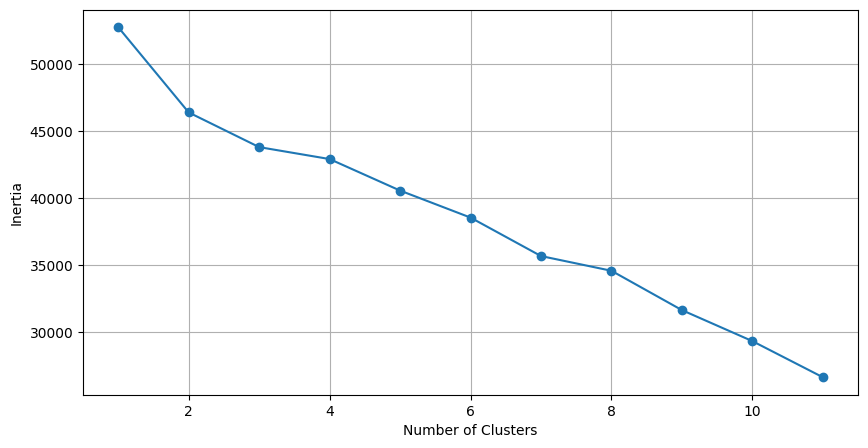

In [8]:
optimise_k_means(new_df,12)

In [9]:
kmeans = KMeans(n_clusters=4)


In [10]:
kmeans.fit(new_df)

KMeans(n_clusters=4)

In [11]:
new_df['kmeans_3'] = kmeans.labels_

In [12]:
pd.set_option('display.max_rows', None)
new_df

SELF MANAGEMENT                                       ...  \
                SM1 SM2 SM3 SM4 SM5 SM6 SM7 SM8 SM9 SM10  ...   
0                 2   2   1   1   1   3   5   4   4    2  ...   
1                 2   2   3   1   3   1   1   2   3    2  ...   
2                 4   4   2   3   2   2   2   5   2    5  ...   
3                 3   2   1   3   4   1   1   1   1    1  ...   
4                 3   2   2   1   5   2   1   1   1    2  ...   
5                 5   1   4   5   5   5   3   4   4    5  ...   
6                 3   5   2   5   2   5   1   3   1    2  ...   
7                 2   2   2   2   3   4   1   2   2    5  ...   
8                 4   5   2   5   4   4   2   3   4    1  ...   
9                 5   4   2   2   1   1   1   5   2    3  ...   
10                3   3   2   3   2   4   2   4   4    3  ...   
11                3   3   3   2   1   1   3   2   2    3  ...   
12                5   5   5   5   3   3   2   3   3    4  ...   
13                3   2   1   3   3   3   1   3   3    5  ...   
14                2   2   1   4   3   5   4   5   3    1  ...   
15                3   3   2   3   3   4   2   3   4    4  ...   
16                3   3   2   3   5   5   4   3   4    2  ...   
17                2   3   2   5   3   4   5   2   1    2  ...   
18                4   4   5   5   4   3   2   2   3    1  ...   
19                3   4   3   2   2   3   1   3   5    2  ...   
20                1   3   2   1   2   1   1   2   3    1  ...   
21                3   3   2   2   3   3   3   2   2    3  ...   
22                3   3   2   2   3   3   3   4   2    2  ...   
23                5   4   3   4   2   5   1   3   2    2  ...   
24                2   2   2   3   3   5   4   3   4    2  ...   
25                4   4   3   2   1   1   1   1   1    1  ...   
26                5   5   2   3   2   3   3   2   2    3  ...   
27                2   1   1   2   2   3   2   3   2    3  ...   
28                2   2   3   2   4   3   3   2   3    4  ...   
29                1   1   1   1   1   4   2   4   3    3  ...   
30                2   2   1   1   1   3   5   4   4    2  ...   
31                2   2   3   1   3   1   1   2   3    2  ...   
32                4   4   2   3   2   2   2   5   2    5  ...   
33                3   2   1   3   4   1   1   1   1    1  ...   
34                3   2   2   1   5   2   1   1   1    2  ...   
35                5   1   4   5   5   5   3   4   4    5  ...   
36                3   5   2   5   2   5   1   3   1    2  ...   
37                2   2   2   2   3   4   1   2   2    5  ...   
38                4   5   2   5   4   4   2   3   4    1  ...   
39                5   4   2   2   1   1   1   5   2    3  ...   
40                3   3   2   3   2   4   2   4   4    3  ...   
41                3   3   3   2   1   1   3   2   2    3  ...   
42                5   5   5   5   3   3   2   3   3    4  ...   
43                3   2   1   3   3   3   1   3   3    5  ...   
44                2   2   1   4   3   5   4   5   3    1  ...   
45                3   3   2   3   3   4   2   3   4    4  ...   
46                3   3   2   3   5   5   4   3   4    2  ...   
47                2   3   2   5   3   4   5   2   1    2  ...   
48                4   4   5   5   4   3   2   2   3    1  ...   
49                3   4   3   2   2   3   1   3   5    2  ...   
50                1   3   2   1   2   1   1   2   3    1  ...   
51                3   3   2   2   3   3   3   2   2    3  ...   
52                3   3   2   2   3   3   3   4   2    2  ...   
53                5   4   3   4   2   5   1   3   2    2  ...   
54                2   2   2   3   3   5   4   3   4    2  ...   
55                4   4   3   2   1   1   1   1   1    1  ...   
56                5   5   2   3   2   3   3   2   2    3  ...   
57                2   1   1   2   2   3   2   3   2    3  ...   
58                2   2   3   2   4   3   3   2   3    4  ...   
59                1   1   1   1   1   4

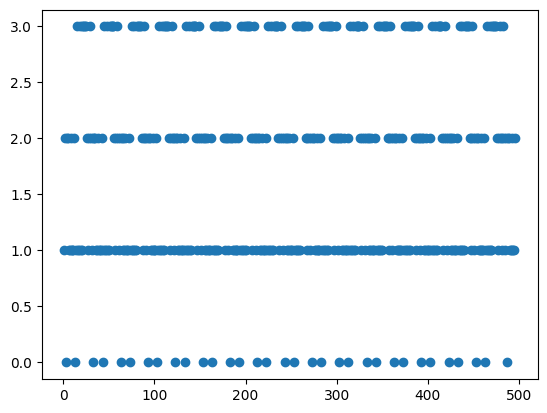

In [13]:
plt.scatter(x=df['Unnamed: 0_level_0'], y=new_df['kmeans_3'])

In [14]:
df

Unnamed: 0_level_0 SELF MANAGEMENT                                  ...  \
     NO OF RESPONDENTS             SM1 SM2 SM3 SM4 SM5 SM6 SM7 SM8 SM9  ...   
0                    1               2   2   1   1   1   3   5   4   4  ...   
1                    2               2   2   3   1   3   1   1   2   3  ...   
2                    3               4   4   2   3   2   2   2   5   2  ...   
3                    4               3   2   1   3   4   1   1   1   1  ...   
4                    5               3   2   2   1   5   2   1   1   1  ...   
5                    6               5   1   4   5   5   5   3   4   4  ...   
6                    7               3   5   2   5   2   5   1   3   1  ...   
7                    8               2   2   2   2   3   4   1   2   2  ...   
8                    9               4   5   2   5   4   4   2   3   4  ...   
9                   10               5   4   2   2   1   1   1   5   2  ...   
10                  11               3   3   2   3   2   4   2   4   4  ...   
11                  12               3   3   3   2   1   1   3   2   2  ...   
12                  13               5   5   5   5   3   3   2   3   3  ...   
13                  14               3   2   1   3   3   3   1   3   3  ...   
14                  15               2   2   1   4   3   5   4   5   3  ...   
15                  16               3   3   2   3   3   4   2   3   4  ...   
16                  17               3   3   2   3   5   5   4   3   4  ...   
17                  18               2   3   2   5   3   4   5   2   1  ...   
18                  19               4   4   5   5   4   3   2   2   3  ...   
19                  20               3   4   3   2   2   3   1   3   5  ...   
20                  21               1   3   2   1   2   1   1   2   3  ...   
21                  22               3   3   2   2   3   3   3   2   2  ...   
22                  23               3   3   2   2   3   3   3   4   2  ...   
23                  24               5   4   3   4   2   5   1   3   2  ...   
24                  25               2   2   2   3   3   5   4   3   4  ...   
25                  26               4   4   3   2   1   1   1   1   1  ...   
26                  27               5   5   2   3   2   3   3   2   2  ...   
27                  28               2   1   1   2   2   3   2   3   2  ...   
28                  29               2   2   3   2   4   3   3   2   3  ...   
29                  30               1   1   1   1   1   4   2   4   3  ...   
30                  31               2   2   1   1   1   3   5   4   4  ...   
31                  32               2   2   3   1   3   1   1   2   3  ...   
32                  33               4   4   2   3   2   2   2   5   2  ...   
33                  34               3   2   1   3   4   1   1   1   1  ...   
34                  35               3   2   2   1   5   2   1   1   1  ...   
35                  36               5   1   4   5   5   5   3   4   4  ...   
36                  37               3   5   2   5   2   5   1   3   1  ...   
37                  38               2   2   2   2   3   4   1   2   2  ...   
38                  39               4   5   2   5   4   4   2   3   4  ...   
39                  40               5   4   2   2   1   1   1   5   2  ...   
40                  41               3   3   2   3   2   4   2   4   4  ...   
41                  42               3   3   3   2   1   1   3   2   2  ...   
42                  43               5   5   5   5   3   3   2   3   3  ...   
43                  44               3   2   1   3   3   3   1   3   3  ...   
44                  45               2   2   1   4   3   5   4   5   3  ...   
45                  46               3   3   2   3   3   4   2   3   4  ...   
46                  47               3   3   2   3   5   5   4   3   4  ...   
47                  48               2   3   2   5   3   4   5   2   1  ...   
48                  49               4   4   5   5   4